Gerando composição para AMAZONIA-1...
Gerando composição para CBERS-4A...
Gerando composição para CBERS-4...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..1023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..1023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..1023].


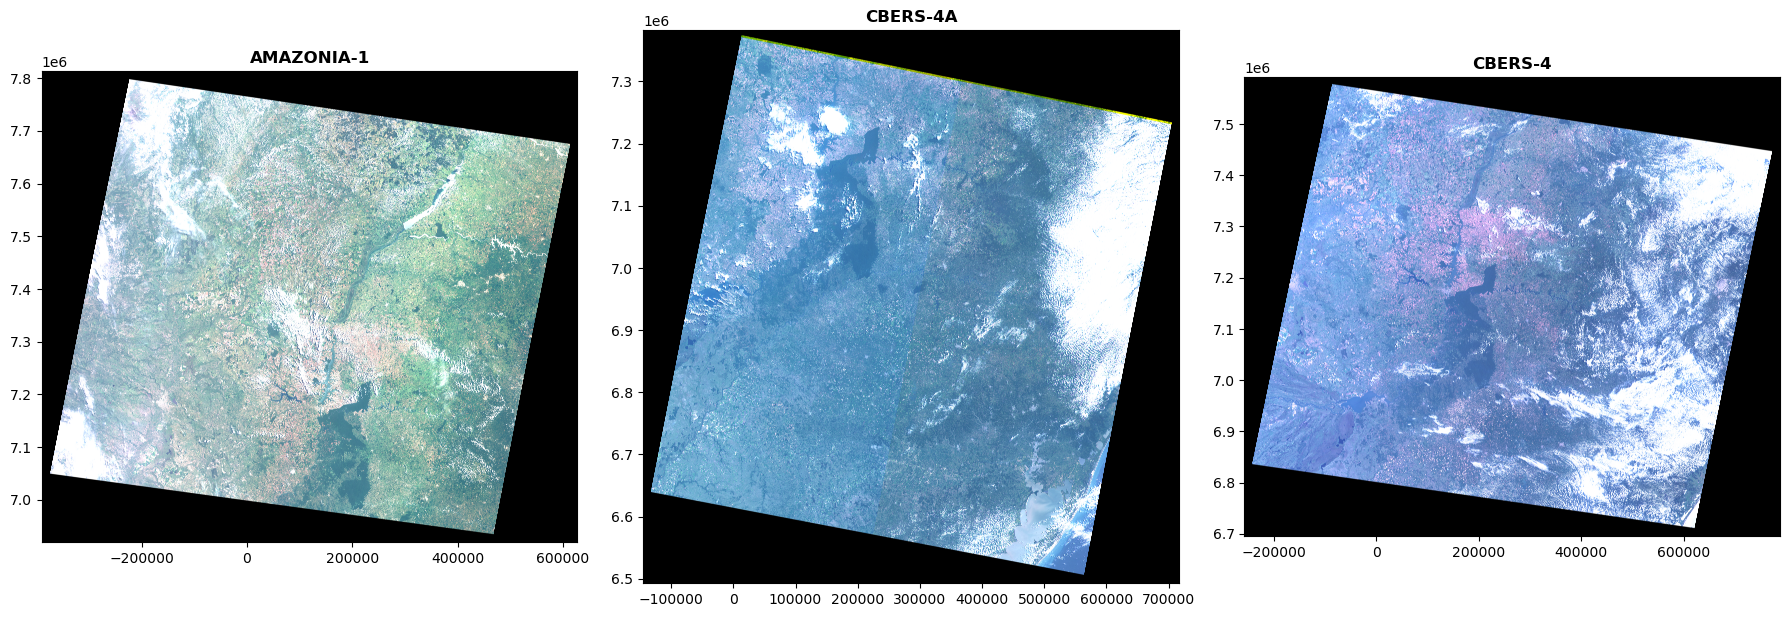

In [3]:
#Adaptado do tutorial https://cbers4asat.readthedocs.io/pt-br/latest/examples/#download-de-produtos por Gabriel Russo
#Composição rgbn dinâmica para as imagens lidas da pasta C:/Users/xavie/cipc-data/raw

import os
import glob
from cbers4asat.tools import rgbn_composite
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt

base_dir = 'C:/Users/xavie/cipc-data/raw/raw'
out_dir = 'C:/Users/xavie/cipc-data/raw/stack'
os.makedirs(out_dir, exist_ok=True)

# Dicionário de mapeamento das bandas: WFI CBERS -> 13, 14, 15, 16. WFI Amazonia1 -> 1, 2, 3, 4
band_mapping = {
    'AMAZONIA-1': {'red': 'BAND3', 'green': 'BAND2', 'blue': 'BAND1', 'nir': 'BAND4'},
    'CBERS-4A': {'red': 'BAND15', 'green': 'BAND14', 'blue': 'BAND13', 'nir': 'BAND16'},
    'CBERS-4': {'red': 'BAND15', 'green': 'BAND14', 'blue': 'BAND13', 'nir': 'BAND16'}
}

processed_files = []
scene_dirs = glob.glob(os.path.join(base_dir, '*'))

# Vamos usar apenas a primeira cena encontrada de cada satelite
sats_found = []

for scene_dir in scene_dirs:
    if not os.path.isdir(scene_dir):
        continue
        
    if 'AMAZONIA1' in scene_dir:
        sat_name = 'AMAZONIA-1'
    elif 'CBERS4A' in scene_dir:
        sat_name = 'CBERS-4A'
    elif 'CBERS4_' in scene_dir:
        sat_name = 'CBERS-4'
    else:
        continue
        
    if sat_name in sats_found:
        continue  # já gerou para este satélite
        
    mapping = band_mapping[sat_name]
    tifs = glob.glob(os.path.join(scene_dir, '*.tif'))
    
    bands_paths = {}
    for color, band_suffix in mapping.items():
        for t in tifs:
            if t.endswith(f"{band_suffix}.tif"):
                bands_paths[color] = t
                break
                
    if len(bands_paths) == 4:
        out_filename = f"{sat_name}_TRUE_COLOR.tif"
        print(f"Gerando composição para {sat_name}...")
        
        # Substitui contrabarras por barras, útil no Windows
        bands_paths = {k: v.replace('\\', '/') for k, v in bands_paths.items()}
        
        rgbn_composite(red=bands_paths['red'],
                       green=bands_paths['green'],
                       blue=bands_paths['blue'],
                       nir=bands_paths['nir'],
                       filename=out_filename,
                       outdir=out_dir)
        
        processed_files.append((sat_name, os.path.join(out_dir, out_filename)))
        sats_found.append(sat_name)

if processed_files:
    fig, ax = plt.subplots(1, len(processed_files), figsize=(6 * len(processed_files), 6))
    if len(processed_files) == 1:
        ax = [ax]
        
    for i, (sat_name, filepath) in enumerate(processed_files):
        raster = rio.open(filepath)
        # Normaliza a visualização caso a imagem seja 10-bit ou mais (opcional para exibição nítida)
        show(raster.read((1,2,3)), transform=raster.transform, ax=ax[i], title=sat_name)
        
    plt.tight_layout()
    plt.show()
